In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
df = pd.read_csv('D:/Important Files/Machine Learning/Datasets/placement.csv')
df.sample(5)

,cgpa,placement_exam_marks,placed
881,7.72,42.0,0
348,6.13,17.0,1
391,7.77,66.0,1
394,7.94,18.0,1
873,7.90,42.0,1


In [3]:
df.shape

(1000, 3)

# Outlier Detection Using the IQR (Interquartile Range) Method

**Category: Feature Transformation** (outlier handling)

The IQR method identifies outliers based on the **spread between the 25th and 75th percentiles** of the data (the "middle 50%"), rather than relying on the mean/standard deviation like the Z-score method. This makes it far more **robust to skewed data and existing outliers**, since it's built on the median-adjacent quartiles rather than metrics that outliers themselves can distort.

---

## Core Formula

**Step 1 — Find the quartiles:**

$$
Q_1 = 25^{th} \text{ percentile}, \qquad Q_3 = 75^{th} \text{ percentile}
$$

**Step 2 — Calculate the IQR (the spread of the middle 50% of data):**

$$
IQR = Q_3 - Q_1
$$

**Step 3 — Calculate the outlier bounds:**

$$
\text{Lower bound} = Q_1 - 1.5 \times IQR
$$

$$
\text{Upper bound} = Q_3 + 1.5 \times IQR
$$

**Step 4 — Flag outliers:**

$$
x < \text{Lower bound} \quad \text{or} \quad x > \text{Upper bound} \quad \Rightarrow \quad \text{outlier}
$$

---

## Why 1.5?

The **1.5× multiplier** is a widely-used convention (introduced by statistician John Tukey), chosen because it works well as a general-purpose threshold across many distributions without needing to assume normality. It's not derived from a strict mathematical law the way the Z-score's "3 standard deviations" ties to the empirical rule — it's a practical heuristic that has become the de facto standard, especially since it's also what **box plots** use to draw their "whiskers."

- **1.5×IQR** → standard/moderate outlier detection (most common default)
- **3×IQR** → used for flagging only "extreme" outliers (a stricter, more conservative cutoff)

---

## Step-by-Step Example

```python
Q1 = df['income'].quantile(0.25)
Q3 = df['income'].quantile(0.75)
IQR = Q3 - Q1

lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

outliers = df[(df['income'] < lower_bound) | (df['income'] > upper_bound)]
```

---

## Two Ways to Handle Flagged Outliers

### 1. Trimming (Removal)

```python
df_trimmed = df[(df['income'] >= lower_bound) & (df['income'] <= upper_bound)]
```
- Same trade-off as always — simple, but loses data.

### 2. Capping

$$
x' =
\begin{cases}
Q_1 - 1.5 \times IQR, & x < Q_1 - 1.5 \times IQR \\
x, & Q_1 - 1.5 \times IQR \leq x \leq Q_3 + 1.5 \times IQR \\
Q_3 + 1.5 \times IQR, & x > Q_3 + 1.5 \times IQR
\end{cases}
$$

```python
df['income'] = df['income'].clip(lower=lower_bound, upper=upper_bound)
```

---

## Visual Connection: Box Plots

The IQR method is exactly what a **box plot** visualizes:

- The **box** spans from Q1 to Q3 (i.e., the IQR itself).
- The **whiskers** extend to the lower/upper bounds (Q1 − 1.5×IQR and Q3 + 1.5×IQR).
- Any points **beyond the whiskers** are plotted as individual dots — these are exactly the "outliers" this method flags.

```python
import seaborn as sns
sns.boxplot(x=df['income'])
```

If you've ever looked at a box plot and wondered what those little dots beyond the whiskers meant — that's the IQR method in action, visually.

---

## Why IQR Is More Robust Than Z-Score

| Aspect | Z-Score | IQR |
|---|---|---|
| Uses | Mean, standard deviation | Median-adjacent quartiles (Q1, Q3) |
| Affected by existing outliers? | ✅ Yes — mean/std get pulled by extreme values | ❌ No — quartiles are positional/rank-based, largely unaffected by extreme values |
| Requires normal distribution? | ✅ Yes (assumes Gaussian) | ❌ No — works on **any distribution shape**, including skewed data |
| Common threshold | ±3 (standard deviations) | 1.5×IQR (or 3×IQR for extreme outliers) |

This is the core reason IQR is often the **default recommendation** for outlier detection in real-world (often skewed) datasets — Z-score's reliance on mean/std means a few extreme outliers can inflate the standard deviation enough to mask other outliers ("outliers hiding outliers"), while IQR's quartile-based approach isn't vulnerable to that same distortion.

---

## IQR vs. Z-Score vs. Percentile — Full Comparison

| Aspect | Z-Score | IQR | Percentile |
|---|---|---|---|
| Basis | Mean & std dev | Q1, Q3, 1.5×IQR | Any chosen percentile |
| Assumes normal distribution? | ✅ Yes | ❌ No | ❌ No |
| Robust to existing outliers? | ❌ No | ✅ Yes | ✅ Yes |
| Threshold flexibility | Fixed (σ multiples) | Semi-fixed (1.5× or 3× convention) | Fully adjustable |
| Visual counterpart | — | Box plot whiskers | — |
| Best for | Roughly Gaussian data | General-purpose, skewed data | Precise control over % flagged |

---

## Where This Fits in the Pipeline

Same principle as the other two methods: compute `Q1`, `Q3`, and `IQR` **only from training data**, then apply those same fixed bounds to transform validation/test data — never recompute quartiles on test data, to avoid leakage. If you're wrapping this in a custom transformer for use inside a `Pipeline`/`GridSearchCV`, `fit()` should store `lower_bound`/`upper_bound` learned from training data, and `transform()` should apply the clip using those stored values.

<Axes: xlabel='placement_exam_marks', ylabel='Count'>

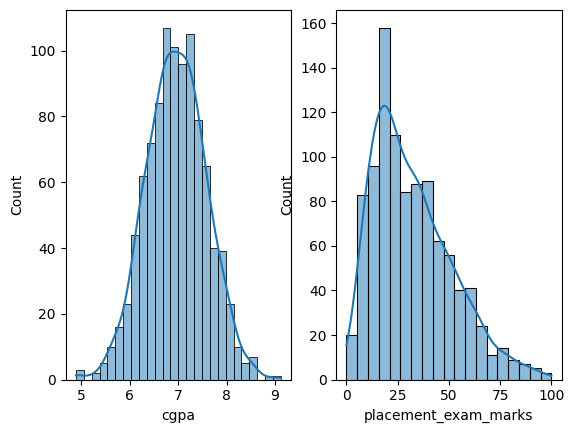

In [4]:
plt.subplot(1,2,1)
sns.histplot(data=df['cgpa'],kde=True)

plt.subplot(1,2,2)
sns.histplot(data=df['placement_exam_marks'],kde=True)

In [5]:
print('Skewness of CGPA: ',df['cgpa'].skew())
print('Skewness of Placement Exam Marks column: ',df['placement_exam_marks'].skew())

Skewness of CGPA:  -0.014529938929314918
Skewness of Placement Exam Marks column:  0.8356419499466834


In [6]:
df['placement_exam_marks'].describe()

count    1000.000000
mean       32.225000
std        19.130822
min         0.000000
25%        17.000000
50%        28.000000
75%        44.000000
max       100.000000
Name: placement_exam_marks, dtype: float64

<Axes: xlabel='placement_exam_marks'>

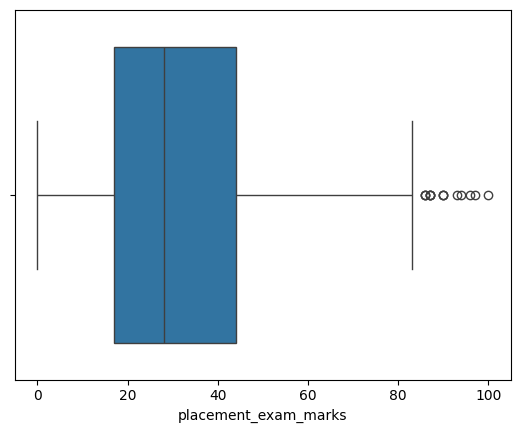

In [7]:
sns.boxplot(data=df['placement_exam_marks'],orient='h')

In [8]:
percentile25 = df['placement_exam_marks'].quantile(0.25)
percentile75 = df['placement_exam_marks'].quantile(0.75)

In [9]:
iqr = percentile75 - percentile25
iqr

np.float64(27.0)

In [10]:
upper_limit = percentile75 + 1.5 * iqr
lower_limit = percentile25 - 1.5 * iqr

In [11]:
print('Upper Limit: ',upper_limit)
print('Lower Limit: ',lower_limit)

Upper Limit:  84.5
Lower Limit:  -23.5


### Finding Outliers:

In [12]:
df[df['placement_exam_marks'] > upper_limit]

,cgpa,placement_exam_marks,placed
9,7.75,94.0,1
40,6.60,86.0,1
61,7.51,86.0,0
134,6.33,93.0,0
162,7.80,90.0,0
283,7.09,87.0,0
290,8.38,87.0,0
311,6.97,87.0,1
324,6.64,90.0,0
630,6.56,96.0,1


In [13]:
df[df['placement_exam_marks'] < lower_limit]

,cgpa,placement_exam_marks,placed


## Trimming (Removal) Technique:

In [14]:
df_new = df[df['placement_exam_marks'] < upper_limit]
df_new

,cgpa,placement_exam_marks,placed
0,7.19,26.0,1
1,7.46,38.0,1
2,7.54,40.0,1
3,6.42,8.0,1
4,7.23,17.0,0
...,...,...,...
995,8.87,44.0,1
996,9.12,65.0,1
997,4.89,34.0,0
998,8.62,46.0,1


<Axes: xlabel='placement_exam_marks'>

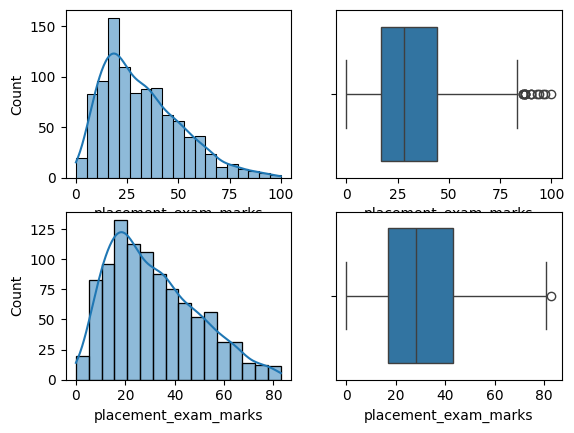

In [21]:
plt.subplot(2,2,1)
sns.histplot(data=df['placement_exam_marks'], kde=True)

plt.subplot(2,2,2)
sns.boxplot(data=df['placement_exam_marks'],orient='h')

plt.subplot(2,2,3)
sns.histplot(data=df_new['placement_exam_marks'], kde=True)

plt.subplot(2,2,4)
sns.boxplot(data=df_new['placement_exam_marks'],orient='h')

In [16]:
df_new.describe()

,cgpa,placement_exam_marks,placed
count,985.000000,985.000000,985.00000
mean,6.961594,31.339086,0.48934
std,0.614734,17.857633,0.50014
min,4.890000,0.000000,0.00000
25%,6.550000,17.000000,0.00000
50%,6.960000,28.000000,0.00000
75%,7.370000,43.000000,1.00000
max,9.120000,83.000000,1.00000


## Capping (Winsorization) Technique:

In [17]:
new_df = df.copy()

new_df['placement_exam_marks'] = np.where(
    new_df['placement_exam_marks'] > upper_limit,
    upper_limit,
    np.where(
        new_df['placement_exam_marks'] < lower_limit,
        lower_limit,
        new_df['placement_exam_marks']
    )
)

In [18]:
new_df.shape

(1000, 3)

<Axes: xlabel='placement_exam_marks'>

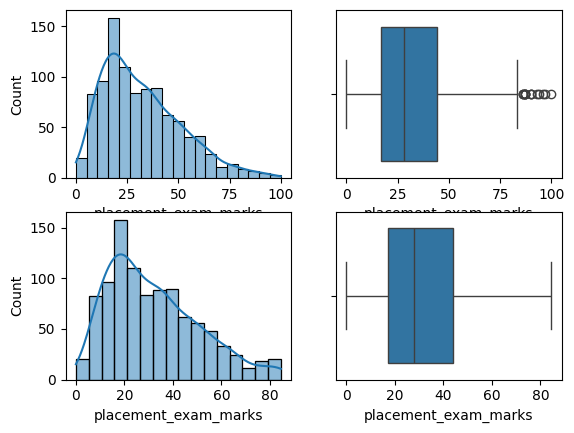

In [20]:
plt.subplot(2,2,1)
sns.histplot(data=df['placement_exam_marks'], kde=True)

plt.subplot(2,2,2)
sns.boxplot(data=df['placement_exam_marks'],orient='h')

plt.subplot(2,2,3)
sns.histplot(data=new_df['placement_exam_marks'], kde=True)

plt.subplot(2,2,4)
sns.boxplot(data=new_df['placement_exam_marks'],orient='h')

In [22]:
new_df.describe()

,cgpa,placement_exam_marks,placed
count,1000.000000,1000.000000,1000.000000
mean,6.961240,32.136500,0.489000
std,0.615898,18.865419,0.500129
min,4.890000,0.000000,0.000000
25%,6.550000,17.000000,0.000000
50%,6.960000,28.000000,0.000000
75%,7.370000,44.000000,1.000000
max,9.120000,84.500000,1.000000
